<a href="https://colab.research.google.com/github/Brayanbrayan/Image-Segmentation/blob/main/ImageSeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

In [3]:
!git config --global user.email "brayannjoroge259@gmail.com"
!git config --global user.name "Brayanbrayan"

In [4]:
!git clone https://github.com/Brayanbrayan/Image-Segmentation.git

Cloning into 'Image-Segmentation'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 2), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 166.32 KiB | 6.16 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [5]:
cd Image-Segmentation/

/content/Image-Segmentation


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [7]:
def cross_entropy_manual(predictions, targets):
    """
    predictions: (N, C, H, W) — raw logits from the network
    targets:     (N, H, W)    — integer class indices per pixel

    Returns: scalar loss
    """
    # Step 1: convert logits to probabilities
    # softmax across the class dimension (dim=1)
    probs = F.softmax(predictions, dim=1)  # (N, C, H, W)

    # Step 2: gather the probability assigned to the correct class
    # targets needs to be (N, 1, H, W) for gather
    targets_expanded = targets.unsqueeze(1)  # (N, 1, H, W)
    correct_class_probs = probs.gather(dim=1, index=targets_expanded)  # (N, 1, H, W)
    correct_class_probs = correct_class_probs.squeeze(1)  # (N, H, W)

    # Step 3: take log and negate
    loss_per_pixel = -torch.log(correct_class_probs + 1e-8)  # (N, H, W)

    # Step 4: average across ALL pixels
    return loss_per_pixel.mean()


# Verify it matches PyTorch's built-in
def cross_entropy_pytorch(predictions, targets):
    """PyTorch's nn.CrossEntropyLoss handles softmax internally"""
    criterion = nn.CrossEntropyLoss()
    return criterion(predictions, targets)


# Quick sanity check
torch.manual_seed(42)
N, C, H, W = 2, 5, 64, 64  # batch=2, classes=5, image=64x64

fake_predictions = torch.randn(N, C, H, W, requires_grad=True)
fake_targets = torch.randint(0, C, (N, H, W))

loss_manual = cross_entropy_manual(fake_predictions, fake_targets)
loss_pytorch = cross_entropy_pytorch(fake_predictions, fake_targets)

print(f"Manual CE loss:  {loss_manual.item():.6f}")
print(f"PyTorch CE loss: {loss_pytorch.item():.6f}")
print(f"Difference: {abs(loss_manual.item() - loss_pytorch.item()):.8f}")
# Should be very close to 0

Manual CE loss:  1.994746
PyTorch CE loss: 1.994746
Difference: 0.00000012


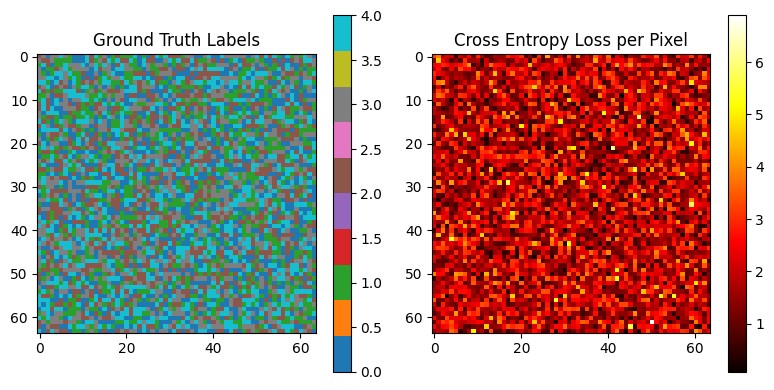

Mean loss: 1.9889
Max loss (hardest pixels): 6.8923
Min loss (easiest pixels): 0.0841


In [8]:
def visualise_ce_loss(predictions, targets, title="Cross Entropy Loss per Pixel"):
    """Show where the loss is high and low across the image"""
    probs = F.softmax(predictions, dim=1)
    targets_expanded = targets.unsqueeze(1)
    correct_class_probs = probs.gather(dim=1, index=targets_expanded).squeeze(1)
    loss_per_pixel = -torch.log(correct_class_probs + 1e-8)

    # Take first image in batch
    loss_map = loss_per_pixel[0].detach().numpy()

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(targets[0].numpy(), cmap='tab10')
    plt.title("Ground Truth Labels")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(loss_map, cmap='hot')
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    print(f"Mean loss: {loss_map.mean():.4f}")
    print(f"Max loss (hardest pixels): {loss_map.max():.4f}")
    print(f"Min loss (easiest pixels): {loss_map.min():.4f}")

visualise_ce_loss(fake_predictions, fake_targets)

In [ ]:
from google.colab import userdata
token = userdata.get('ImageSeg')
!git push https://{token}@github.com/Brayanbrayan/Image-Segmentation.git

Everything up-to-date


In [9]:
%cd /content/Image-Segmentation

/content/Image-Segmentation


In [ ]:
!git pull

fatal: not a git repository (or any of the parent directories): .git


Partial Cross Entropy

In [10]:
def simulate_point_labels(targets, num_points_per_class=5):
    """
    Takes a full ground truth mask and simulates sparse point annotations.

    targets: (N, H, W) integer class labels
    num_points_per_class: how many points to keep per class per image

    Returns:
        sparse_targets: (N, H, W) — same as targets but 255 where unlabelled
        point_mask:     (N, H, W) — 1 where labelled, 0 everywhere else
    """
    N, H, W = targets.shape
    point_mask = torch.zeros_like(targets, dtype=torch.float32)
    sparse_targets = torch.full_like(targets, 255)  # 255 = ignore index

    for n in range(N):
        classes = targets[n].unique()
        for cls in classes:
            # Find all pixels of this class
            class_pixels = (targets[n] == cls).nonzero(as_tuple=False)

            if len(class_pixels) == 0:
                continue

            # Randomly sample num_points_per_class from them
            num_to_sample = min(num_points_per_class, len(class_pixels))
            indices = torch.randperm(len(class_pixels))[:num_to_sample]
            sampled = class_pixels[indices]

            for pixel in sampled:
                h, w = pixel[0], pixel[1]
                point_mask[n, h, w] = 1.0
                sparse_targets[n, h, w] = targets[n, h, w]

    return sparse_targets, point_mask


def partial_cross_entropy(predictions, targets, point_mask):
    """
    Partial CE loss — only computed at labelled points.

    predictions: (N, C, H, W) — raw logits
    targets:     (N, H, W)    — class indices, 255 where unlabelled
    point_mask:  (N, H, W)    — 1 at labelled pixels, 0 elsewhere

    Returns: scalar loss
    """
    # Standard CE but ignore_index=255 handles unlabelled pixels
    # However we also apply the mask explicitly for clarity

    probs = F.softmax(predictions, dim=1)

    # Only process labelled pixels
    targets_expanded = targets.unsqueeze(1).clone()
    # Replace ignore index with 0 temporarily to avoid index errors
    targets_safe = targets.clone()
    targets_safe[targets_safe == 255] = 0

    targets_expanded = targets_safe.unsqueeze(1)
    correct_class_probs = probs.gather(dim=1, index=targets_expanded).squeeze(1)

    # Per-pixel CE loss
    loss_per_pixel = -torch.log(correct_class_probs + 1e-8)

    # Apply the mask — zero out unlabelled pixels
    masked_loss = loss_per_pixel * point_mask

    # Average only over labelled pixels
    num_labelled = point_mask.sum()
    if num_labelled == 0:
        return torch.tensor(0.0, requires_grad=True)

    return masked_loss.sum() / num_labelled


# Test it
sparse_targets, point_mask = simulate_point_labels(fake_targets, num_points_per_class=5)

print(f"Total pixels: {fake_targets.numel()}")
print(f"Labelled pixels: {int(point_mask.sum().item())}")
print(f"Percentage labelled: {100*point_mask.sum()/fake_targets.numel():.2f}%")

loss_partial = partial_cross_entropy(fake_predictions, sparse_targets, point_mask)
loss_full = cross_entropy_pytorch(fake_predictions, fake_targets)

print(f"\nFull CE loss (all pixels):     {loss_full.item():.6f}")
print(f"Partial CE loss (points only): {loss_partial.item():.6f}")

Total pixels: 8192
Labelled pixels: 50
Percentage labelled: 0.61%

Full CE loss (all pixels):     1.994746
Partial CE loss (points only): 2.221952


Visualise the difference

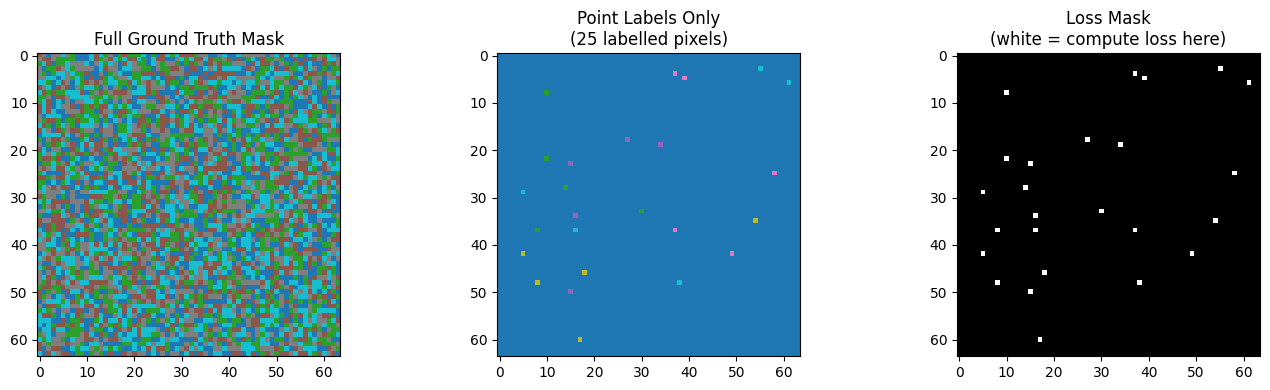

In [11]:
def visualise_partial_vs_full(predictions, targets, point_mask):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Ground truth
    axes[0].imshow(targets[0].numpy(), cmap='tab10')
    axes[0].set_title("Full Ground Truth Mask")

    # Point labels only
    visible = targets[0].float().clone()
    visible[point_mask[0] == 0] = -1
    axes[1].imshow(visible.numpy(), cmap='tab10')
    axes[1].set_title(f"Point Labels Only\n({int(point_mask[0].sum())} labelled pixels)")

    # Loss mask
    axes[2].imshow(point_mask[0].numpy(), cmap='gray')
    axes[2].set_title("Loss Mask\n(white = compute loss here)")

    plt.tight_layout()
    plt.show()

visualise_partial_vs_full(fake_predictions, fake_targets, point_mask)

In [ ]:
%cd /content/Image-Segmentation/
!git log -1

/content/Image-Segmentation
commit f8ffdc209431c54ebff5e8dbd5e32f62b6b2d58e (HEAD -> main, origin/main, origin/HEAD)
Author: Brayanbrayan <108278064+Brayanbrayan@users.noreply.github.com>
Date:   Sat Jun 13 16:23:10 2026 +0300

    Created a colab notebook


In [ ]:
# 1. Ensure you are in the repository directory
%cd /content/Image-Segmentation/

# 2. Create a temporary testing file
!echo "Testing GitHub pipeline from Colab" > connection_test.txt

# 3. Stage and commit the test file
!git add connection_test.txt
!git commit -m "test: verifying colab push workflow"

# 4. Push to your remote repository (change 'main' to 'master' if your branch uses the old naming)
!git push origin main

/content/Image-Segmentation
[main 185e85f] test: verifying colab push workflow
 1 file changed, 1 insertion(+)
 create mode 100644 connection_test.txt
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
from google.colab import userdata
token = userdata.get('ImageSeg')
!git push https://{token}@github.com/Brayanbrayan/Image-Segmentation.git

Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (2/2), done.
Writing objects: 100% (3/3), 383 bytes | 383.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Brayanbrayan/Image-Segmentation.git
   f8ffdc2..185e85f  main -> main


Add Focal Loss

In [12]:
def partial_focal_ce(predictions, targets, point_mask, gamma=2.0):
    """
    Partial Focal Cross Entropy — the actual formula from the PDF.

    pfCE = Σ(FocalLoss(pred, GT) × MASK_labelled) / Σ MASK_labelled

    gamma: focusing parameter. 0 = standard CE, 2 = standard focal
    """
    probs = F.softmax(predictions, dim=1)

    targets_safe = targets.clone()
    targets_safe[targets_safe == 255] = 0

    targets_expanded = targets_safe.unsqueeze(1)
    correct_class_probs = probs.gather(dim=1, index=targets_expanded).squeeze(1)

    # Standard CE
    ce_loss = -torch.log(correct_class_probs + 1e-8)

    # Focal modulating factor — down-weights easy examples
    focal_weight = (1 - correct_class_probs) ** gamma

    # Focal loss per pixel
    focal_loss_per_pixel = focal_weight * ce_loss

    # Apply point mask
    masked_loss = focal_loss_per_pixel * point_mask

    # Average over labelled pixels only
    num_labelled = point_mask.sum()
    if num_labelled == 0:
        return torch.tensor(0.0, requires_grad=True)

    return masked_loss.sum() / num_labelled


# Compare all three
loss_full_ce      = cross_entropy_pytorch(fake_predictions, fake_targets)
loss_partial_ce   = partial_cross_entropy(fake_predictions, sparse_targets, point_mask)
loss_partial_focal = partial_focal_ce(fake_predictions, sparse_targets, point_mask, gamma=2.0)

print("Loss comparison:")
print(f"  Full CE (all pixels):          {loss_full_ce.item():.6f}")
print(f"  Partial CE (points only):      {loss_partial_ce.item():.6f}")
print(f"  Partial Focal CE (points only): {loss_partial_focal.item():.6f}")

# Verify gradients flow
loss_partial_focal.backward()
print("\nGradients flow correctly through partial focal CE")

Loss comparison:
  Full CE (all pixels):          1.994746
  Partial CE (points only):      2.221952
  Partial Focal CE (points only): 1.819789

Gradients flow correctly through partial focal CE


Visualizing the Differences

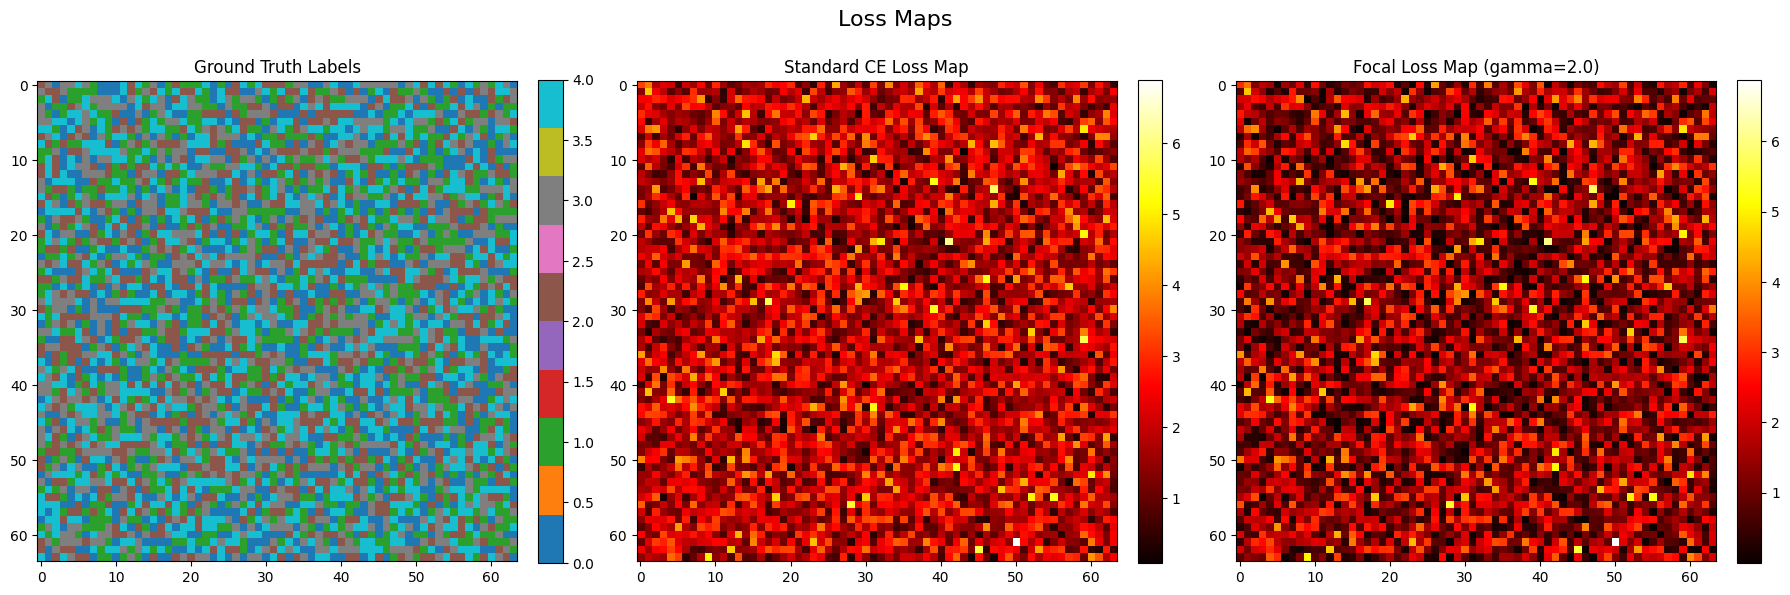

In [13]:
def calculate_and_visualize_loss_maps(predictions, targets, gamma=2.0, title_prefix="Loss Maps"):
    probs = F.softmax(predictions, dim=1)
    targets_safe = targets.clone()

    # Ensure targets_safe doesn't contain 255 if it's not handled by gather
    # For full CE, we assume targets are proper class labels, no ignore_index

    targets_expanded = targets_safe.unsqueeze(1)
    correct_class_probs = probs.gather(dim=1, index=targets_expanded).squeeze(1)

    # Standard CE per pixel
    ce_loss_per_pixel = -torch.log(correct_class_probs + 1e-8)

    # Focal modulating factor
    focal_weight = (1 - correct_class_probs) ** gamma

    # Focal loss per pixel
    focal_loss_per_pixel = focal_weight * ce_loss_per_pixel

    # Detach and convert to numpy for plotting
    ce_map = ce_loss_per_pixel[0].detach().cpu().numpy()
    focal_map = focal_loss_per_pixel[0].detach().cpu().numpy()
    gt_map = targets[0].detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot Ground Truth
    im0 = axes[0].imshow(gt_map, cmap='tab10')
    axes[0].set_title("Ground Truth Labels")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Plot Standard CE Loss Map
    im1 = axes[1].imshow(ce_map, cmap='hot')
    axes[1].set_title("Standard CE Loss Map")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Plot Focal Loss Map
    im2 = axes[2].imshow(focal_map, cmap='hot')
    axes[2].set_title(f"Focal Loss Map (gamma={gamma})")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

# Call the function with our fake data
calculate_and_visualize_loss_maps(fake_predictions, fake_targets, gamma=2.0)


In [ ]:
!git add ImageSeg.ipynb
!git commit -m "Added pFCE and some visualization for comparison"

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


Choosing the Dataset.

In [14]:
# Download LandCover.ai dataset
!pip install gdown -q
!wget -q https://landcover.ai.linuxpolska.com/download/landcover.ai.v1.zip -O landcover.zip
!unzip -q landcover.zip -d landcover_data
!ls landcover_data

images	masks  split.py  test.txt  train.txt  val.txt


In [15]:
import os

image_files = sorted(os.listdir('landcover_data/images'))
mask_files = sorted(os.listdir('landcover_data/masks'))

print(f"Number of images: {len(image_files)}")
print(f"Number of masks: {len(mask_files)}")
print(f"Sample image filenames: {image_files[:5]}")
print(f"Sample mask filenames: {mask_files[:5]}")

# Check the train/val/test split files
with open('landcover_data/train.txt') as f:
    train_list = f.read().splitlines()
print(f"\nTraining samples: {len(train_list)}")
print(f"Sample entries: {train_list[:3]}")

Number of images: 41
Number of masks: 41
Sample image filenames: ['M-33-20-D-c-4-2.tif', 'M-33-20-D-d-3-3.tif', 'M-33-32-B-b-4-4.tif', 'M-33-48-A-c-4-4.tif', 'M-33-7-A-d-2-3.tif']
Sample mask filenames: ['M-33-20-D-c-4-2.tif', 'M-33-20-D-d-3-3.tif', 'M-33-32-B-b-4-4.tif', 'M-33-48-A-c-4-4.tif', 'M-33-7-A-d-2-3.tif']

Training samples: 7470
Sample entries: ['M-33-20-D-c-4-2_0', 'M-33-20-D-c-4-2_1', 'M-33-20-D-c-4-2_10']


In [16]:
# Inspect actual image and mask sizes and values
from PIL import Image
import numpy as np

sample_img = Image.open(f'landcover_data/images/{image_files[0]}')
sample_mask = Image.open(f'landcover_data/masks/{mask_files[0]}')

print(f"Image size: {sample_img.size}, mode: {sample_img.mode}")
print(f"Mask size: {sample_mask.size}, mode: {sample_mask.mode}")

mask_array = np.array(sample_mask)
print(f"Mask unique values (these are your class indices): {np.unique(mask_array)}")

Image size: (9095, 9636), mode: RGB
Mask size: (9095, 9636), mode: L
Mask unique values (these are your class indices): [0 1 2 3 4]


In [17]:
# Check what split.py does
with open('landcover_data/split.py') as f:
    print(f.read())

#!/usr/bin/env python3

import glob
import os

import cv2

IMGS_DIR = "./images"
MASKS_DIR = "./masks"
OUTPUT_DIR = "./output"

TARGET_SIZE = 512

img_paths = glob.glob(os.path.join(IMGS_DIR, "*.tif"))
mask_paths = glob.glob(os.path.join(MASKS_DIR, "*.tif"))

img_paths.sort()
mask_paths.sort()

os.makedirs(OUTPUT_DIR)
for i, (img_path, mask_path) in enumerate(zip(img_paths, mask_paths)):
    img_filename = os.path.splitext(os.path.basename(img_path))[0]
    mask_filename = os.path.splitext(os.path.basename(mask_path))[0]
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path)

    assert img_filename == mask_filename and img.shape[:2] == mask.shape[:2]

    k = 0
    for y in range(0, img.shape[0], TARGET_SIZE):
        for x in range(0, img.shape[1], TARGET_SIZE):
            img_tile = img[y:y + TARGET_SIZE, x:x + TARGET_SIZE]
            mask_tile = mask[y:y + TARGET_SIZE, x:x + TARGET_SIZE]

            if img_tile.shape[0] == TARGET_SIZE and img_tile.shape[1] == TARGET_SIZ

In [18]:
!ls /content/

Image-Segmentation  sample_data


In [19]:
# Run the tiling script
%cd landcover_data
!python split.py
%cd ..

/content/Image-Segmentation/landcover_data
[ WARN:0@0.057] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@0.057] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33918 (0x847e) encountered
[ WARN:0@0.057] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@0.057] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@0.057] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34736 (0x87b0) encountered
[ WARN:0@0.057] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@1.613] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1.613] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field w

In [20]:
# Verify the output
import os
output_files = sorted(os.listdir('landcover_data/output'))
print(f"Total tiled files: {len(output_files)}")
print(f"Sample files: {output_files[:6]}")

img_tiles = [f for f in output_files if not f.endswith('_m.png')]
mask_tiles = [f for f in output_files if f.endswith('_m.png')]
print(f"Image tiles: {len(img_tiles)}")
print(f"Mask tiles: {len(mask_tiles)}")

Total tiled files: 21348
Sample files: ['M-33-20-D-c-4-2_0.jpg', 'M-33-20-D-c-4-2_0_m.png', 'M-33-20-D-c-4-2_1.jpg', 'M-33-20-D-c-4-2_10.jpg', 'M-33-20-D-c-4-2_100.jpg', 'M-33-20-D-c-4-2_100_m.png']
Image tiles: 10674
Mask tiles: 10674


Dataset class with point-label simulation built in

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torchvision.transforms.functional as TF

class LandCoverPointDataset(Dataset):
    def __init__(self, output_dir, file_list, num_points_per_class=5, img_size=256):
        self.output_dir = output_dir
        self.file_list = file_list  # list of base filenames like "M-33-20-D-c-4-2_0"
        self.num_points_per_class = num_points_per_class
        self.img_size = img_size

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        base_name = self.file_list[idx]
        img_path = os.path.join(self.output_dir, f"{base_name}.jpg")
        mask_path = os.path.join(self.output_dir, f"{base_name}_m.png")

        image = Image.open(img_path).convert("RGB").resize((self.img_size, self.img_size))
        mask = Image.open(mask_path).convert("L").resize((self.img_size, self.img_size), Image.NEAREST)

        image = TF.to_tensor(image)  # (3, H, W), scaled to [0,1]
        mask = torch.from_numpy(np.array(mask)).long()  # (H, W)

        sparse_target, point_mask = simulate_point_labels_single(mask, self.num_points_per_class)

        return image, mask, sparse_target, point_mask


def simulate_point_labels_single(mask, num_points_per_class):
    """Single-image version of point simulation for use inside Dataset.__getitem__"""
    H, W = mask.shape
    point_mask = torch.zeros_like(mask, dtype=torch.float32)
    sparse_target = torch.full_like(mask, 255)

    for cls in mask.unique():
        class_pixels = (mask == cls).nonzero(as_tuple=False)
        if len(class_pixels) == 0:
            continue
        num_to_sample = min(num_points_per_class, len(class_pixels))
        indices = torch.randperm(len(class_pixels))[:num_to_sample]
        sampled = class_pixels[indices]
        for pixel in sampled:
            h, w = pixel[0].item(), pixel[1].item()
            point_mask[h, w] = 1.0
            sparse_target[h, w] = mask[h, w]

    return sparse_target, point_mask

In [22]:
# Build file lists from the actual tiled output (ignore train.txt/val.txt since
# those reference the original un-tiled split — we use our own random split)
import random

base_names = sorted(set(f.replace('_m.png', '').replace('.jpg', '')
                         for f in img_tiles))
random.seed(42)
random.shuffle(base_names)

split_idx = int(0.85 * len(base_names))
train_names = base_names[:split_idx]
val_names = base_names[split_idx:]

print(f"Train tiles: {len(train_names)}")
print(f"Val tiles: {len(val_names)}")

Train tiles: 9072
Val tiles: 1602


In [23]:
# Create datasets and loaders
train_dataset = LandCoverPointDataset('landcover_data/output', train_names,
                                       num_points_per_class=5, img_size=256)
val_dataset = LandCoverPointDataset('landcover_data/output', val_names,
                                     num_points_per_class=5, img_size=256)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

# Sanity check one batch
images, masks, sparse_targets, point_masks = next(iter(train_loader))
print(f"Images batch shape: {images.shape}")
print(f"Masks batch shape: {masks.shape}")
print(f"Point mask batch shape: {point_masks.shape}")
print(f"Avg labelled pixels per image: {point_masks.sum(dim=[1,2]).mean().item():.1f}")

Images batch shape: torch.Size([8, 3, 256, 256])
Masks batch shape: torch.Size([8, 256, 256])
Point mask batch shape: torch.Size([8, 256, 256])
Avg labelled pixels per image: 12.5


Unet Declaration

In [25]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """Two conv layers with batch norm and ReLU — the basic U-Net block"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """
    Small U-Net for segmentation.
    Encoder downsamples 4 times, decoder upsamples 4 times with skip connections.
    """
    def __init__(self, in_channels=3, num_classes=5, base_channels=32):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels*2)
        self.enc3 = DoubleConv(base_channels*2, base_channels*4)
        self.enc4 = DoubleConv(base_channels*4, base_channels*8)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(base_channels*8, base_channels*16)

        # Decoder
        self.up4 = nn.ConvTranspose2d(base_channels*16, base_channels*8, 2, stride=2)
        self.dec4 = DoubleConv(base_channels*16, base_channels*8)

        self.up3 = nn.ConvTranspose2d(base_channels*8, base_channels*4, 2, stride=2)
        self.dec3 = DoubleConv(base_channels*8, base_channels*4)

        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, stride=2)
        self.dec2 = DoubleConv(base_channels*4, base_channels*2)

        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, 2, stride=2)
        self.dec1 = DoubleConv(base_channels*2, base_channels)

        # Final classifier — 1x1 conv to get class logits per pixel
        self.final = nn.Conv2d(base_channels, num_classes, 1)

    def forward(self, x):
        # Encoder path — save outputs for skip connections
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder path — concatenate skip connections
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)


# Sanity check — verify shapes work
model = UNet(in_channels=3, num_classes=5, base_channels=32)
test_input = torch.randn(2, 3, 256, 256)
test_output = model(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {test_output.shape}")  # should be (2, 5, 256, 256)

num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 5, 256, 256])
Total parameters: 7,766,117


Training loop

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = UNet(in_channels=3, num_classes=5, base_channels=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def compute_iou(pred, target, num_classes=5, ignore_index=255):
    """Mean IoU across classes, ignoring the 255 ignore label"""
    pred = pred.argmax(dim=1)  # (N, H, W)
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        valid = (target != ignore_index)

        intersection = (pred_cls & target_cls & valid).sum().float()
        union = ((pred_cls | target_cls) & valid).sum().float()

        if union == 0:
            continue
        ious.append((intersection / union).item())
    return np.mean(ious) if ious else 0.0


def train_epoch(model, loader, optimizer, device, gamma=2.0):
    model.train()
    total_loss = 0
    for batch_idx, (images, full_masks, sparse_targets, point_masks) in enumerate(loader):
        images = images.to(device)
        sparse_targets = sparse_targets.to(device)
        point_masks = point_masks.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = partial_focal_ce(predictions, sparse_targets, point_masks, gamma=gamma)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.4f}")

    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    total_iou = 0
    with torch.no_grad():
        for images, full_masks, sparse_targets, point_masks in loader:
            images = images.to(device)
            full_masks = full_masks.to(device)
            predictions = model(images)
            iou = compute_iou(predictions, full_masks)
            total_iou += iou
    return total_iou / len(loader)

Using device: cuda


In [29]:
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of training samples: {len(train_dataset)}")

Number of batches in train_loader: 1134
Number of training samples: 9072


In [31]:
import inspect
print(inspect.getsource(train_epoch))

def train_epoch(model, loader, optimizer, device, gamma=2.0):
    model.train()
    total_loss = 0
    for batch_idx, (images, full_masks, sparse_targets, point_masks) in enumerate(loader):
        images = images.to(device)
        sparse_targets = sparse_targets.to(device)
        point_masks = point_masks.to(device)
        
        optimizer.zero_grad()
        predictions = model(images)
        loss = partial_focal_ce(predictions, sparse_targets, point_masks, gamma=gamma)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if batch_idx % 20 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.4f}")
    
    return total_loss / len(loader)



In [32]:
import time

print("Attempting to fetch one batch...")
start = time.time()
images, full_masks, sparse_targets, point_masks = next(iter(train_loader))
print(f"Fetched one batch in {time.time() - start:.2f} seconds")
print(images.shape, sparse_targets.shape, point_masks.shape)

Attempting to fetch one batch...
Fetched one batch in 0.62 seconds
torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256]) torch.Size([8, 256, 256])


In [33]:
model.train()
images = images.to(device)
sparse_targets = sparse_targets.to(device)
point_masks = point_masks.to(device)

print("Running forward pass...")
start = time.time()
predictions = model(images)
print(f"Forward pass done in {time.time()-start:.2f}s, shape: {predictions.shape}")

print("Computing loss...")
loss = partial_focal_ce(predictions, sparse_targets, point_masks, gamma=2.0)
print(f"Loss: {loss.item()}")

print("Running backward pass...")
start = time.time()
loss.backward()
print(f"Backward pass done in {time.time()-start:.2f}s")

Running forward pass...
Forward pass done in 0.96s, shape: torch.Size([8, 5, 256, 256])
Computing loss...
Loss: 1.2606834173202515
Running backward pass...
Backward pass done in 0.26s


In [35]:
# Run this in a fresh cell while the training cell is still running
# It will tell you if Colab's runtime is actually busy
import IPython
print("If you see this immediately, the kernel is free")

If you see this immediately, the kernel is free


In [36]:
import torch
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

0.120653824 GB allocated
2.386558976 GB reserved


In [37]:
print("before model creation")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("after device set, before model creation")

model = UNet(in_channels=3, num_classes=5, base_channels=32).to(device)
print("model created and moved to device")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print("optimizer created")

before model creation
Using device: cuda
after device set, before model creation
model created and moved to device
optimizer created


In [38]:
print("about to start training loop")
num_epochs = 15
history = {'train_loss': [], 'val_iou': []}

print("history initialized, entering loop")
for epoch in range(num_epochs):
    print(f"inside loop, epoch {epoch} starting")
    train_loss = train_epoch(model, train_loader, optimizer, device)
    print(f"train_epoch returned: {train_loss}")
    val_iou = evaluate(model, val_loader, device)
    print(f"evaluate returned: {val_iou}")

    history['train_loss'].append(train_loss)
    history['val_iou'].append(val_iou)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val mIoU: {val_iou:.4f}")

about to start training loop
history initialized, entering loop
inside loop, epoch 0 starting
  Batch 0/1134 | Loss: 1.1360
  Batch 20/1134 | Loss: 0.8738
  Batch 40/1134 | Loss: 0.7015
  Batch 60/1134 | Loss: 0.7347
  Batch 80/1134 | Loss: 0.5024
  Batch 100/1134 | Loss: 0.6734
  Batch 120/1134 | Loss: 0.5547
  Batch 140/1134 | Loss: 0.6060
  Batch 160/1134 | Loss: 0.6668
  Batch 180/1134 | Loss: 0.3425
  Batch 200/1134 | Loss: 0.5872
  Batch 220/1134 | Loss: 0.6188
  Batch 240/1134 | Loss: 0.2620
  Batch 260/1134 | Loss: 0.4153
  Batch 280/1134 | Loss: 0.4832
  Batch 300/1134 | Loss: 0.7603
  Batch 320/1134 | Loss: 0.5526
  Batch 340/1134 | Loss: 0.4021
  Batch 360/1134 | Loss: 0.5370
  Batch 380/1134 | Loss: 0.3263
  Batch 400/1134 | Loss: 0.6810
  Batch 420/1134 | Loss: 0.3856
  Batch 440/1134 | Loss: 0.3552
  Batch 460/1134 | Loss: 0.5829
  Batch 480/1134 | Loss: 0.4679
  Batch 500/1134 | Loss: 0.4960
  Batch 520/1134 | Loss: 0.5173
  Batch 540/1134 | Loss: 0.7041
  Batch 560/1134

KeyboardInterrupt: 